In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

reglog = LogisticRegression()

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

In [8]:
display(df.describe())

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000
mean,-8.438037e+15,1.173357e+16,7.841814e+15,1.027042e+16,-6.786316e+15,9.540475e+15,0.503000
std,9.539351e+15,1.153940e+16,1.103329e+16,1.039960e+16,9.990352e+15,1.194975e+16,0.500241
min,-7.864163e+16,2.480999e+12,2.936875e+06,6.999357e+12,-3.899531e+16,4.244220e+13,0.000000
25%,-9.399621e+15,2.630805e+15,2.866232e+15,5.575667e+15,-1.305271e+16,4.518518e+15,0.000000
50%,-7.989082e+15,4.768309e+15,3.392643e+15,8.587714e+15,-2.791614e+15,6.874559e+15,1.000000
75%,-5.870395e+15,1.908988e+16,4.171801e+15,1.268923e+16,-3.051710e+14,9.713771e+15,1.000000
max,-9.296770e+12,7.123235e+16,4.724941e+16,6.686140e+16,1.797384e+16,7.895620e+16,1.000000


0.64


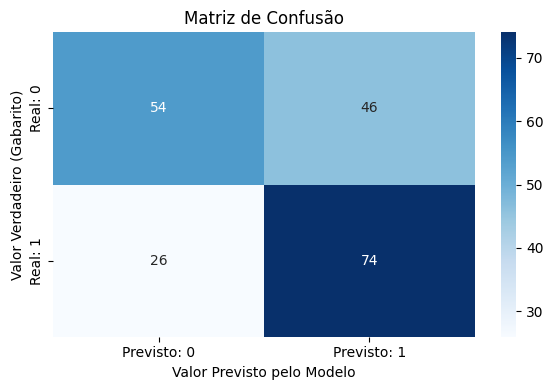

In [14]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

reglog.fit(X_train,Y_train)

Y_predict = reglog.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()